# INTRODUCTION 

This project aims to classify the medium of artworks using machine learning techniques. The dataset contains textual descriptions, captions, titles, and structured metadata such as dimensions and categories.
The objective is to predict the artwork medium (e.g., oil_on_canvas, watercolor, ink, etc.).
This is a multi-class classification problem that involves Natural Language Processing (NLP) and tabular data analysis.

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
#Loading datasets
train = pd.read_csv("train_n (1) (2).csv")
test = pd.read_csv("test_n (1) (3).csv")
sample = pd.read_csv("sample_submission (2).csv")

In [3]:
train.head()

,id,Unnamed: 0,acc,acc_id,loc,t,dt,y0,y1,ts,...,tp,ord,txt,tag,note,eff,cat,img,cap,y
0,2929,2929,1,1983.1.14,NaN,Beach Scene at Trouville,1863,1863.0,1863.0,1851 to 1875,...,NaN,NaN,NaN,NaN,NaN,NaN,painted surface|Beach|Trouville|French Paintin...,https://api.nga.gov/iiif/85f2142e-1b34-4e75-a0...,A oil on wood artwork titled 'Beach Scene at T...,4
1,3224,3224,1,1951.16.5,NaN,Playing Cards,15th century,1400.0,1499.0,1300 to 1400,...,NaN,NaN,NaN,NaN,NaN,NaN,Lombard,https://api.nga.gov/iiif/717a802a-4449-4cf6-8b...,A print artwork titled 'Playing Cards' by Unkn...,5
2,3351,3351,1,2008.115.2454,NaN,Agriculture,1939,1939.0,1939.0,1926 to 1950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://api.nga.gov/iiif/5b8cada2-0d67-45bb-96...,A print artwork titled 'Agriculture' by Unknow...,5
3,1736,1736,1,1958.9.7,NaN,"Burning of Old South Church, Bath, Maine",c. 1854,1854.0,1854.0,1851 to 1875,...,previous_attribution,1.0,American 19th Century,American 19th Century,Attribution at time of gift,NaN,"American|Bath, ME|Old South Church|American Na...",https://api.nga.gov/iiif/c8befcd8-4237-4652-ba...,A oil on canvas artwork titled 'Burning of Old...,2
4,1813,1813,1,1963.10.52,13181.0,Le gourmet,1901,1901.0,1901.0,1901 to 1925,...,NaN,NaN,NaN,NaN,NaN,NaN,Eating|Twentieth and Twenty-first Century Pain...,https://api.nga.gov/iiif/e19a2b28-639c-4d6a-84...,A oil on canvas artwork titled 'Le gourmet' by...,2


In [4]:
train.columns

Index(['id', 'Unnamed: 0', 'acc', 'acc_id', 'loc', 't', 'dt', 'y0', 'y1', 'ts',
       'dim', 'inscription', 'markings', 'attributioninverted', 'attribution',
       'provenancetext', 'creditline', 'classification', 'subclassification',
       'visualbrowserclassification', 'parentid', 'isvirtual',
       'departmentabbr', 'portfolio', 'series', 'volume', 'watermarks',
       'lastdetectedmodification', 'wikidataid', 'customprinturl', 'label',
       'uuid', 'iiifurl', 'iiifthumburl', 'viewtype', 'sequence', 'width',
       'height', 'maxpixels', 'created', 'modified', 'depictstmsobjectid',
       'assistivetext', 'element', 'dimensiontype', 'dimension', 'unitname',
       'tp', 'ord', 'txt', 'tag', 'note', 'eff', 'cat', 'img', 'cap', 'y'],
      dtype='object')

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           4000 non-null   int64  
 1   Unnamed: 0                   4000 non-null   int64  
 2   acc                          4000 non-null   int64  
 3   acc_id                       4000 non-null   object 
 4   loc                          667 non-null    float64
 5   t                            4000 non-null   object 
 6   dt                           3746 non-null   object 
 7   y0                           3999 non-null   float64
 8   y1                           3999 non-null   float64
 9   ts                           3999 non-null   object 
 10  dim                          3768 non-null   object 
 11  inscription                  2333 non-null   object 
 12  markings                     166 non-null    object 
 13  attributioninverte

# EDA
Target Variable Analysis

We analyze the distribution of artwork mediums to understand class balance.

In [6]:
train['y'].value_counts()

y
7    611
2    571
0    500
3    490
4    485
5    482
6    449
1    412
Name: count, dtype: int64

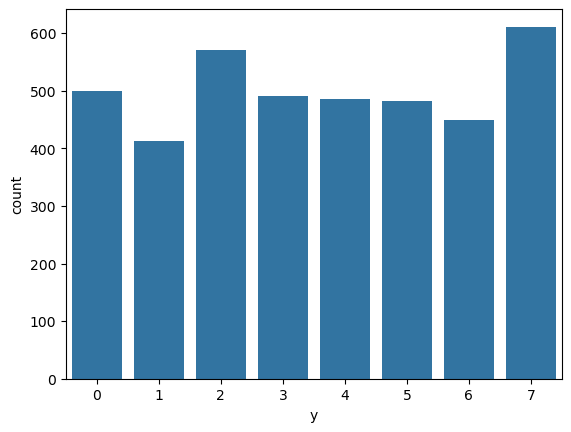

In [7]:
sns.countplot(x='y', data=train)
plt.show()

Missing Values

We check for missing values in the dataset to ensure proper data cleaning.

In [8]:
train.isnull().sum()

id                                0
Unnamed: 0                        0
acc                               0
acc_id                            0
loc                            3333
t                                 0
dt                              254
y0                                1
y1                                1
ts                                1
dim                             232
inscription                    1667
markings                       3834
attributioninverted               0
attribution                       0
provenancetext                  584
creditline                        0
classification                    0
subclassification              3893
visualbrowserclassification       0
parentid                       3690
isvirtual                         0
departmentabbr                    0
portfolio                      3626
series                         3615
volume                         3994
watermarks                     3839
lastdetectedmodification    

## Text Preprocessing
Text data plays a crucial role in this problem as it contains important clues about the artwork medium. We combine multiple text fields and clean the text to make it suitable for machine learning models.

In [9]:
train['text'] = (train['t'].fillna('') + " " +train['txt'].fillna('') + " " +train['cap'].fillna('') + " " +train['tag'].fillna('') + " " +train['note'].fillna(''))
test['text'] = (test['t'].fillna('') + " " +test['txt'].fillna('') + " " +test['cap'].fillna('') + " " +test['tag'].fillna('') + " " +test['note'].fillna(''))

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

train['text'] = train['text'].apply(clean_text)
test['text'] = test['text'].apply(clean_text)

## Feature Engineering
We extract useful features from structured data such as dimensions and categories to improve model performance.

In [11]:
keywords = ['oil', 'canvas', 'wood', 'panel', 'ink', 'watercolor', 'tempera', 'print']

for word in keywords:
    train[f'has_{word}'] = train['text'].str.contains(word).astype(int)
    test[f'has_{word}'] = test['text'].str.contains(word).astype(int)

In [12]:
print([col for col in train.columns if 'has_' in col])

['has_oil', 'has_canvas', 'has_wood', 'has_panel', 'has_ink', 'has_watercolor', 'has_tempera', 'has_print']


In [13]:
train['area'] = train['width'].fillna(0) * train['height'].fillna(0)
test['area'] = test['width'].fillna(0) * test['height'].fillna(0)

In [14]:
train_cat = pd.get_dummies(train['cat'], drop_first=True)
test_cat = pd.get_dummies(test['cat'], drop_first=True)

In [15]:
train_cat = train_cat.astype(float)
test_cat = test_cat.astype(float)

In [16]:
train_cat, test_cat = train_cat.align(test_cat, join='left', axis=1, fill_value=0)

## Text Vectorization
We convert textual data into numerical form using TF-IDF vectorization. This helps the model understand the importance of words and phrases.

In [32]:
train['year'] = train['y0'].fillna(train['y1']).fillna(0)
test['year'] = test['y0'].fillna(test['y1']).fillna(0)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=8000,ngram_range=(1,2),stop_words='english')
X_text_train = tfidf.fit_transform(train['text'])
X_text_test = tfidf.transform(test['text'])

## Feature Combination
We combine text features and structured features to create the final dataset for model training.

In [48]:
from scipy.sparse import hstack, csr_matrix
keyword_cols = [f'has_{w}' for w in keywords]
final_cols = ['area', 'year'] + keyword_cols
X_train = hstack([X_text_train,train_cat,csr_matrix(train[final_cols])])
X_test = hstack([X_text_test,test_cat,csr_matrix(test[final_cols])])
y = train['y']

# Model Training
We split the dataset into training and validation sets to evaluate model performance.

In [49]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y, test_size=0.2, random_state=42)

## Logistic Regression
Logistic Regression is used as a baseline model for classification.

In [50]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_tr, y_tr)
pred_lr = lr.predict(X_val)
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_val, pred_lr))

Logistic Regression Accuracy: 0.2125


## Random Forest
Random Forest is used to capture non-linear relationships in the data.

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300,max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=42,n_jobs=-1)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_val)
print("RF Accuracy:", accuracy_score(y_val, pred_rf))

RF Accuracy: 0.96375


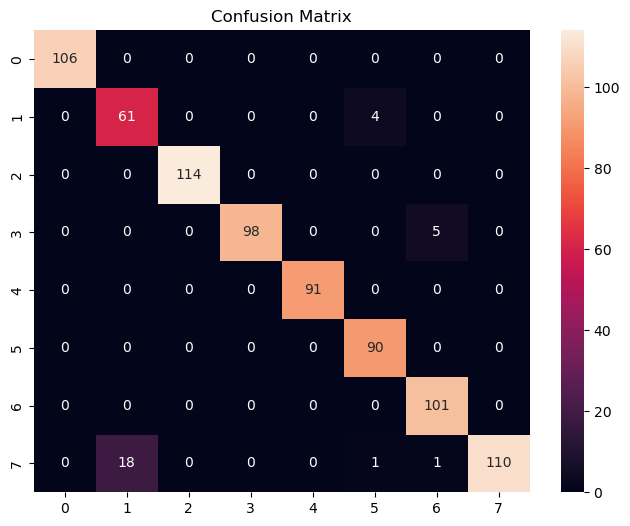

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## XGBoost
XGBoost is used as the main model due to its strong performance with structured and text features.

In [52]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,use_label_encoder=False,eval_metric='mlogloss')
xgb.fit(X_tr, y_tr)
pred_xgb = xgb.predict(X_val)
print("XGBoost Accuracy:", accuracy_score(y_val, pred_xgb))

C:\Users\LENOVO\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:29:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.96125


# Model Comparison
We compare the performance of different models based on accuracy.

In [40]:
print("LR:", accuracy_score(y_val, pred_lr))
print("RF:", accuracy_score(y_val, pred_rf))
print("XGB:", accuracy_score(y_val, pred_xgb))

LR: 0.1425
RF: 0.96375
XGB: 0.96


In [41]:
rf.fit(X_train, y)
test_preds = rf.predict(X_test)

In [72]:
submission = pd.DataFrame({'id': test['id'],'y': test_preds})
submission.to_csv("FINAL_SUBMISSION_KAGGLE.csv", index=False)

## Final Model Selection

Among all models, Random Forest achieved the highest accuracy of 96.37%, outperforming both Logistic Regression and XGBoost.

This indicates that Random Forest is better suited for capturing complex relationships in the dataset, especially with combined textual and structured features.

Hence, Random Forest was selected as the final model for prediction.

The poor performance of Logistic Regression suggests that the dataset is not linearly separable and requires more complex models.

### Model Performance Analysis

- Logistic Regression performed poorly due to the non-linear nature of the data.
- Random Forest and XGBoost performed significantly better, indicating the presence of complex feature interactions.
- Random Forest achieved the highest accuracy and was selected as the final model.